# Analyze Beta Diversity

This notebook assesses differences in overall microbial community composition between BF and EU children using beta diversity analyses.

From the OMA tutorial book: `https://microbiome.github.io/OMA/docs/devel/pages/community_similarity.html`

"Beta diversity quantifies the dissimilarity between communities (multiple samples), as opposed to alpha diversity, which focuses on variation within a community (one sample). "

### Notes 

#### Bray-Curtis

Bray-Curtis measures how different 2 samples are, based on abundances of the features (here, ASVs / taxa) that they contain. 

Values are from 0 (identical) to 1 (com)

calculated as a distance matrix , so for every pair   
samples A and B:  
BC distance _ AB = sum_i (A_i - B_i) / sum_i (A_i + B_i)     
where A_i and B_i are read counts for ASV i  

#### Jaccard

Jaccard similarity measures how similar two sets (here: microbial communities) are based on which elements (taxa) are present or absent, without considering their abundances.


#### Aitchison

"Aitchison distance (Euclidean distance for clr-transformed abundances, aiming to avoid the compositionality bias)"
`https://bioconductor.org/books/release/OMA/pages/community_similarity.html`

#### UniFrac

Unweighted UniFrac measures differences in community composition based on the presence or absence of taxa and their phylogenetic relationships, whereas weighted UniFrac additionally accounts for taxon relative abundance.

#### PCoA 

Principal coordinates analysis (PCoA) reduces a distance matrix into a smaller number of dimensions, allowing the relationships between samples to be visualized.

note: PCA on a data matrix ≈ PCoA on the Euclidean distance matrix calculated from that data.
but only if the data is appropriately centered


from the OMA Tutorial: `https://bioconductor.org/books/release/OMA/pages/community_similarity.html`
"Unsupervised ordination methods analyze variation in the data without additional information on covariates or other supervision of the model. Among the different approaches, Multi-Dimensional Scaling (MDS) and non-metric MDS (NMDS) can be regarded as the standard. They are jointly referred to as PCoA. For this demonstration, we will analyze beta diversity in GlobalPatterns, and observe the variation between stool samples and samples of differing origin."


#### PERMDISP

PERMDISP tests whether groups differ in how variable or heterogeneous their communities are

"Permutation test for homogeneity of multivariate dispersions"

`https://bioconductor.org/books/release/OMA/pages/community_similarity.html` : 
"It is important to note that the application of PERMANOVA assumes homogeneous group dispersions (variances). This can be tested with the PERMDISP2 method (Anderson 2006) by using the same assay and distance method as in PERMANOVA."




#### PERMANOVA



From OMA Tutorial: `https://bioconductor.org/books/release/OMA/pages/community_similarity.html`

"PERMANOVA (Permutational Multivariate Analysis of Variance) (Anderson 2001) can be seen as a non-parametric, multivariate extension of ANOVA (Analysis of Variance). It is used to compare groups in multivariate data and to assess whether a variable explains differences in the data. PERMANOVA first calculates the dissimilarities between samples, then compares the centroids (multivariate means) of each group to determine if they differ significantly."

"It is important to note that the application of PERMANOVA assumes homogeneous group dispersions (variances)."



### Import Libraries

In [224]:
suppressPackageStartupMessages({

########### main libraries ###########
library(SummarizedExperiment)
library(TreeSummarizedExperiment)
library(mia)
library(miaViz) # mia visualizatioon
library(vegan) # ecol stats (beta diversity)
library(ape) # reads trees

########### data manipulation tools ###########
library(tidyverse)
library(tibble)
library(scales)

########### visualization libraries ###########   
library(ggrepel)
library(patchwork)
library(scater)

library(knitr)

########### resource management tools ###########
# library(tictoc)

################ notes ####################
### loaded by tidyverse
# library(ggplot2)
# library(tidyr)
# library(dplyr)
# library(readr)
# library(stringr)

})

warnLevel <- getOption('warn')
options(warn = -1)

### Arguments Piped in with R script Conversion

In [225]:
args <- commandArgs(trailingOnly = TRUE)
if (length(args) >= 2) {
    PROJECT_NAME <- args[1]
    PROJECT_DIR  <- normalizePath(args[2])
} else {
    # defaults for notebook 
    PROJECT_NAME <- "ERP000133"
    PROJECT_DIR  <- normalizePath("..")
}

### Input File Paths (not piped in if R script)

In [226]:
ANALYSIS_DIR <- file.path(PROJECT_DIR, "analysis")
ALPHA_DIV_DIR <-  file.path(ANALYSIS_DIR, "alpha_div")


In [227]:

tse <- readRDS( file = file.path(ALPHA_DIV_DIR, paste0(PROJECT_NAME, ".tse.withAlphaDiv.rds")))
tse_genus <- readRDS( file = file.path(ALPHA_DIV_DIR, paste0(PROJECT_NAME, ".tse_genus.withAlphaDiv.rds")))
tse_phylum <- readRDS( file = file.path(ALPHA_DIV_DIR, paste0(PROJECT_NAME, ".tse_phylum.withAlphaDiv.rds")))
metadata <- as.data.frame(colData(tse))



### Make Output Directory

In [228]:
# make file output directory if it doesn't already exist
ANALYSIS_DIR <- file.path(PROJECT_DIR, "analysis")
BETA_DIV_DIR <-  file.path(ANALYSIS_DIR, "beta_div")
FIG_DIR <- file.path(PROJECT_DIR, "figures")
FIG_BETA_DIV_DIR <- file.path(FIG_DIR, "beta_div")
dir.create(ANALYSIS_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(BETA_DIV_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_BETA_DIV_DIR, recursive = TRUE, showWarnings = FALSE)

REPORT_TABLE_DIR <- file.path(PROJECT_DIR, "report_tables")
SUMMARY_TABLE_DIR <- file.path(PROJECT_DIR, "summary_tables") # more extensive tables not for the report go here
dir.create(REPORT_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(SUMMARY_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)


QUARTO_PLOT_TABLE_DIR <- file.path(PROJECT_DIR, "quarto_plot_tables")
dir.create(QUARTO_PLOT_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)

### Set Global Parameters

In [229]:
population_levels <- unique(colData(tse)$population_group)
# Dynamically assign colors to values in population_group
population_levels <- unique(colData(tse)$population_group)

population_colors <- setNames(
    grDevices::hcl.colors(
        length(population_levels),
        palette = "Dark 3"
    ),
    population_levels
)

# population_colors

In [262]:
baseSizeA = 16
titleSizeA = 18
dotSizeA = 4
axisTitleSizeA = 15
axisTextSizeA = 15
figureTitleSizeA = 25
legendTitleSizeA = 11

### Initialize Holding Lists for Analyses

In [231]:
beta_div_metrics = c('BrayCurtis', 'Jaccard', 'Aitchison', 'Unifrac_weighted',  'Unifrac_unweighted')


stats_list = list()
obj_list = list()
stats_list[['BrayCurtis']] = list()
stats_list[['Jaccard']] = list()
stats_list[['Aitchison']] = list()
stats_list[['Unifrac_weighted']] = list()
stats_list[['Unifrac_unweighted']] = list()
plots_list = list()





title_list = list()

title_list[['BrayCurtis']] = "Bray-Curtis PCoA"
title_list[['Jaccard']] = "Jaccard PCoA"
title_list[['Aitchison']] = "Aitchison PCA"
title_list[['Unifrac_weighted']] = "Weighted UniFrac PCoA"
title_list[['Unifrac_unweighted']] = "Unweighted UniFrac PCoA"






### Functions

In [263]:
### PCoA
run_pcoa <- function(
    distance_object,
    metadata1
) {
    # run pcoa
    pcoa_object <- ape::pcoa(distance_object)
    # extract just the Eigenvalues, Relative_eig
    scores <- as.data.frame(
        pcoa_object$vectors[, 1:2]
    )
    # save rownames as sample, merge scores with metadata
    scores$sample <- rownames(scores)
    scores <- scores %>%
        left_join(
            metadata1 %>%
                rownames_to_column("sample"),
            by = "sample"
        )

    # extract percent variation explained
    percent_variation <- round(
        100 * pcoa_object$values$Relative_eig[1:2],
        1
    )
    return_list = list()
    return_list[['pcoa']] = pcoa_object
    return_list[['scores']] = scores
    return_list[['percent']] = percent_variation
    return(return_list)
}


In [264]:
### PCoA plot function

plot_pcoa <- function(
    pcoa_return1,
    metadata1,
    plot_title,
    group_var ,
    popColors
) {

    pcoa1 = pcoa_return1[['pcoa']]
    scores = pcoa_return1[['scores']]
    percent_variation = pcoa_return1[['percent']]
    
 p1 <-    ggplot(
        scores,
        aes(
            x = Axis.1,
            y = Axis.2,
            color = .data[[group_var]]
        )
    ) +
        geom_point(size = dotSizeA) +
        scale_color_manual(values = popColors) +
        labs(
            title = plot_title,
            x = paste0("PCoA1 (", percent_variation[1], "%)"),
            y = paste0("PCoA2 (", percent_variation[2], "%)"),
            color = "Population"
        ) +
        theme_minimal(base_size = baseSizeA) +
        theme(
            plot.title = element_text(
                face = "bold",
                hjust = 0.5, 
                size = titleSizeA
            ),
            axis.title = element_text(face = "bold", size = axisTitleSizeA),
            legend.title = element_text(face = "bold", size = legendTitleSizeA)
        )

    return(p1)
}


In [265]:
### PCA result extraction
extract_pca <- function(
    tse1,
    metadata1,
    pca_name = "PCA"
) {
    # extract PCA object from reducedDims
    pca_object <- reducedDim(
        tse1,
        pca_name
    )
    # extract PCA scores
    scores <- as.data.frame(
        pca_object
    )
    # save rownames as sample, merge scores with metadata
    scores$sample <- rownames(scores)
    scores <- scores %>%
        left_join(
            metadata1 %>%
                rownames_to_column("sample"),
            by = "sample"
        )
    # extract percent variation explained
    percent_variation <- attr(
        pca_object,
        "percentVar"
    )

    if (!is.null(percent_variation)) {
        percent_variation <- round(
            percent_variation,
            1
        )
    }
    # extract all PCA attributes
    pca_attributes <- attributes(
        pca_object
    )
    return_list = list()

    return_list[['pca']] = pca_object
    return_list[['scores']] = scores
    return_list[['percent']] = percent_variation
    return_list[['attributes']] = pca_attributes

    return(return_list)
}

## Beta Diversity Metrics

### Bray-Curtis

In [235]:
tse_rel <- transformAssay(
    tse,
    assay.type = "counts",
    method = "relabundance"
)

rel_mat <- t(
    assay(tse_rel, "relabundance")
)

stats_list[['BrayCurtis']][['Dist']]  <- vegdist(
    rel_mat,
    method = "bray"
)


### Jaccard

In [236]:
count_mat <- t(
    assay(tse, "counts")
)

# get jaccard distance matrix
stats_list[['Jaccard']][['Dist']] <- vegdist(
    count_mat,
    method = "jaccard",
    binary = TRUE
)

### Aitchison

#### CLR & Aitchison Main

In [237]:

# Centered Log-Ratio (CLR)  transform ASVs
tse_clr <- transformAssay(
    tse,
    assay.type = "counts",
    method = "clr",
    pseudocount = TRUE
)

# transpose the matrix 
clr_mat <- t(
    assay(tse_clr, "clr")
)


stats_list[['Aitchison']][['Dist']] <- dist(
    clr_mat,
    method = "euclidean"
)

A pseudocount of 1 was applied.



#### Aitchison PCA

In [238]:
# run PCA
tse_clr <- runPCA(
    tse_clr,
    assay.type = "clr",
    name = "PCA",
    ncomponents = 10,
    BSPARAM = BiocSingular::ExactParam()
)



stats_list[['Aitchison']][['PCA']] <- extract_pca(
    tse1 = tse_clr,
    metadata1 = metadata,
    pca_name = "PCA"
) 
stats_list[['Aitchison']][['CLR_TSE']] = tse_clr


In [266]:
# plot PCA (only one, not making a function)
plots_list[['Aitchison']]  <- plotReducedDim(
        tse_clr,
        dimred = "PCA",
        colour_by = "population_group"
    ) +
        labs(
            title = title_list[['Aitchison']],
            color = "Population"
        ) +
        theme_minimal(base_size = baseSizeA) +
        theme(
            plot.title = element_text(
                face = "bold",
                hjust = 0.5, 
                size = titleSizeA
            ),
            axis.title = element_text(face = "bold", size = axisTitleSizeA  ),
            # legend.title = element_text(face = "bold"),
            legend.position = "none"
        ) +
        scale_color_manual(
            values = population_colors,
            name = "Population"
        )

plots_list[["Aitchison"]]$layers[[1]]$aes_params$size <- dotSizeA

# plots_list[['Aitchison']] 

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


#### Unweighted UniFrac

In [267]:
stats_list[['Unifrac_unweighted']][['Dist']] <- calculateUnifrac(
    tse,
    assay.type = "counts",
    weighted = FALSE
)

stats_list[['Unifrac_unweighted']][['Dist']] <- as.dist(stats_list[['Unifrac_unweighted']][['Dist']])

#### Weighted UniFrac

In [268]:
stats_list[['Unifrac_weighted']][['Dist']] <- calculateUnifrac(
    tse,
    assay.type = "counts",
    weighted = TRUE
)

stats_list[['Unifrac_weighted']][['Dist']] <- as.dist(stats_list[['Unifrac_weighted']][['Dist']])

### Run PERMDISP & PERMANOVA for all beta diversity distance metrics

In [272]:
for (beta_div1 in beta_div_metrics) {
    print(beta_div1)

    if (beta_div1 == 'Aitchison'){ # PCA performed elsewhere
        cat('')
    } else {

        # run PCoA, keep the stats
        stats_list[[beta_div1]][['PCoA']] <- run_pcoa(distance_object = stats_list[[beta_div1]][['Dist']] , 
                                              metadata1 = metadata) 

        options(repr.plot.width = 10, repr.plot.height = 8)
        plots_list[[beta_div1]] <-  plot_pcoa(
                        pcoa_return1 = stats_list[[beta_div1]][['PCoA']],
                        metadata1 = metadata,
                        plot_title = title_list[[beta_div1]],
                        group_var = "population_group",
                        popColors = population_colors
                    ) 
        # print(plots_list[[beta_div1]])
    }

    ## PERMANOVA
    set.seed(123)

    stats_list[[beta_div1]][['PERMANOVA']] <- adonis2(
        stats_list[[beta_div1]][['Dist']] ~ population_group,
        data = metadata,
        permutations = 9999
    )

    ### PERMDISP
    stats_list[[beta_div1]][["Dispersion"]] <- betadisper(
        stats_list[[beta_div1]][['Dist']],
        metadata$population_group
    )

    stats_list[[beta_div1]][['PERMDISP']] <- permutest(
        stats_list[[beta_div1]][["Dispersion"]],
        permutations = 9999
    )
}

[1] "BrayCurtis"
[1] "Jaccard"
[1] "Aitchison"
[1] "Unifrac_weighted"
[1] "Unifrac_unweighted"


### Make Full Beta diversity figure

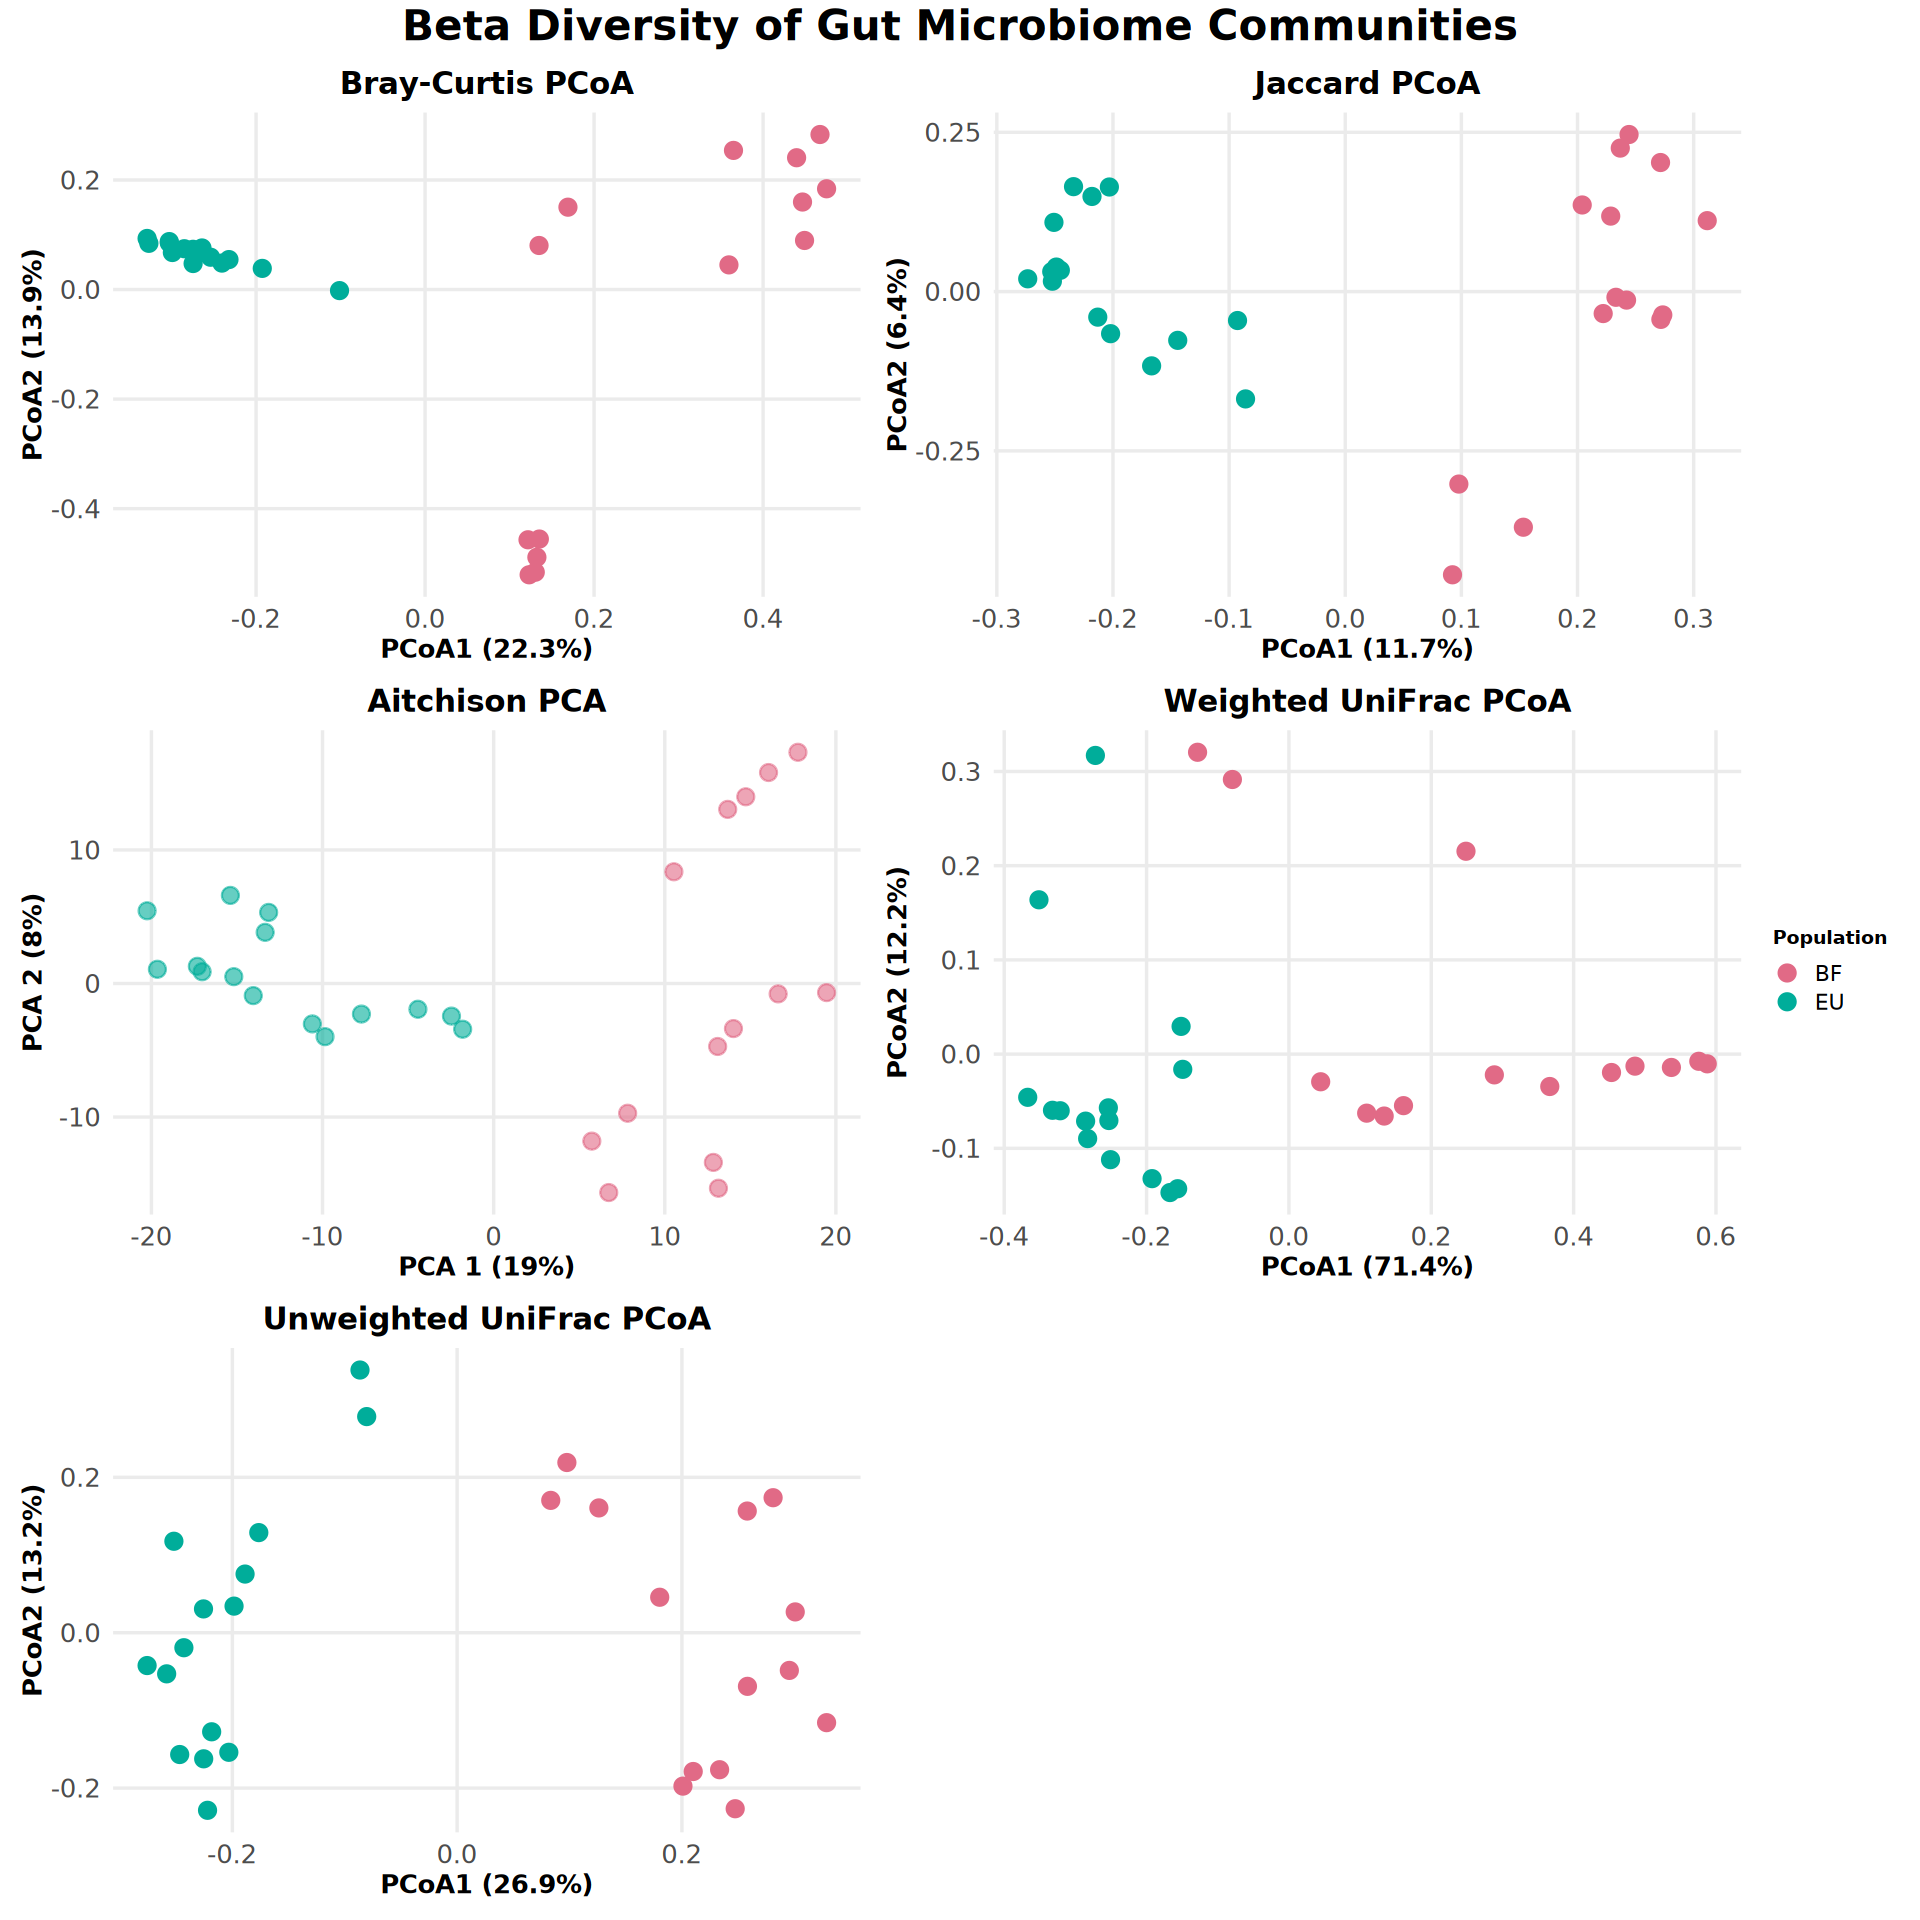

In [270]:
options(repr.plot.width = 16, repr.plot.height = 16)

p_beta <- (
    plots_list[["BrayCurtis"]] + 
    plots_list[["Jaccard"]] + 
    plots_list[["Aitchison"]] + 
    plots_list[["Unifrac_weighted"]] + 
    plots_list[["Unifrac_unweighted"]]
) +
    plot_layout(
        ncol = 2,
        guides = "collect"
    ) +
    plot_annotation(
        title = "Beta Diversity of Gut Microbiome Communities",
        theme = theme(
            plot.title = element_text(
                face = "bold",
                hjust = 0.5,
                size = figureTitleSizeA
            )
        )
    ) &
    theme(
        axis.title = element_text(
            face = "bold",
            size = axisTitleSizeA
        ),
        axis.text = element_text(
            size = axisTextSizeA
        ),
        legend.title = element_text(
            face = "bold"
        ),
        panel.grid.minor = element_blank()
    )

p_beta

In [271]:

# save figure 
# main 
ggsave(
    filename = paste0(FIG_BETA_DIV_DIR, '/', PROJECT_NAME, '.beta_diversity.PCA_PCoA.png'),
    plot = p_beta,
    width = 16,
    height = 16,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_BETA_DIV_DIR, '/', PROJECT_NAME, '.beta_diversity.PCA_PCoA.pdf'),
    plot = p_beta,
    width = 16,
    height = 16,
    units = "in",
    bg = "white"
)


saveRDS(plots_list, file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".beta_diversity.PCA_PCoA.plotList.tsv")))




## Merge Statistics Tables

In [276]:
extract_permanovas <- function(
    stats_list,
    beta_div_metrics
) {

    permanova_table <- do.call(
        rbind,
        lapply(beta_div_metrics, function(metric) {

            x <- as.data.frame(
                stats_list[[metric]][["PERMANOVA"]]
            )

            x$Term <- rownames(x)
            rownames(x) <- NULL

            x$Metric <- metric

            # Put identifying columns first
            x <- x[, c(
                "Metric",
                "Term",
                setdiff(
                    colnames(x),
                    c("Metric", "Term")
                )
            )]

            return(x)
        })
    )

    rownames(permanova_table) <- NULL

    return(permanova_table)
}


extract_permanova_results <- function(
    stats_list,
    beta_div_metrics
) {

    results <- do.call(
        rbind,
        lapply(beta_div_metrics, function(metric) {

            x <- as.data.frame(
                stats_list[[metric]][["PERMANOVA"]]
            )

            data.frame(
                Metric = metric,
                Df = x$Df[1],
                SumOfSqs = x$SumOfSqs[1],
                R2 = x$R2[1],
                F = x$F[1],
                p_value = x$`Pr(>F)`[1]
            )
        })
    )

    rownames(results) <- NULL

    results$p_adj_BH <- p.adjust(
        results$p_value,
        method = "BH"
    )

    return(results)
}

In [277]:
permanova_table <- extract_permanovas(
    stats_list = stats_list,
    beta_div_metrics = beta_div_metrics
)

permanova_table

Metric,Term,Df,SumOfSqs,R2,F,Pr(>F)
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BrayCurtis,Model,1,2.316447,0.2056379,6.989539,1e-04
BrayCurtis,Residual,27,8.948241,0.7943621,NA,NA
BrayCurtis,Total,28,11.264689,1.0000000,NA,NA
Jaccard,Model,1,1.350593,0.1113249,3.382309,1e-04
Jaccard,Residual,27,10.781394,0.8886751,NA,NA
Jaccard,Total,28,12.131987,1.0000000,NA,NA
Aitchison,Model,1,5092.803394,0.1417891,4.460799,1e-04
Aitchison,Residual,27,30825.352663,0.8582109,NA,NA
Aitchison,Total,28,35918.156057,1.0000000,NA,NA


In [308]:

write_tsv( 
    permanova_table,
    file = file.path(SUMMARY_TABLE_DIR, paste0(PROJECT_NAME, ".beta_diversity.permanova.stats.tsv")),
    quote = "needed"
)


In [278]:
permanova_results <- extract_permanova_results(
    stats_list,
    beta_div_metrics
)

permanova_results

Metric,Df,SumOfSqs,R2,F,p_value,p_adj_BH
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BrayCurtis,1,2.316447,0.2056379,6.989539,1e-04,1e-04
Jaccard,1,1.350593,0.1113249,3.382309,1e-04,1e-04
Aitchison,1,5092.803394,0.1417891,4.460799,1e-04,1e-04
Unifrac_weighted,1,2.034619,0.5187375,29.102436,1e-04,1e-04
Unifrac_unweighted,1,1.352240,0.2505038,9.024197,1e-04,1e-04


In [317]:
# write to quarto folder so i can make figure for main
write_tsv( 
    permanova_results,
    file = file.path(REPORT_TABLE_DIR, paste0(PROJECT_NAME, ".beta_diversity.permanova.statsShort.tsv")),
    quote = "needed"
)


In [310]:
extract_permdisp_results <- function(
    stats_list,
    beta_div_metrics
) {
    results <- do.call(
        rbind,
        lapply(beta_div_metrics, function(metric) {
            x <- stats_list[[metric]][["PERMDISP"]]
            data.frame(
                Metric = metric,
                Df = x$tab[1, "Df"],
                F = x$tab[1, "F"],
                p_value = x$tab[1, "Pr(>F)"]
            )
        })
    )
    rownames(results) <- NULL
    # mult test correction across distance metrics
    results$p_adj_BH <- p.adjust(
        results$p_value,
        method = "BH"
    )

    return(results)
}

In [311]:
permdisp_results <- extract_permdisp_results(
    stats_list = stats_list,
    beta_div_metrics = beta_div_metrics
)

permdisp_results

Metric,Df,F,p_value,p_adj_BH
<chr>,<int>,<dbl>,<dbl>,<dbl>
BrayCurtis,1,0.73784168,0.3912,0.590375
Jaccard,1,0.03827688,0.8535,0.853500
Aitchison,1,6.62143216,0.0154,0.077000
Unifrac_weighted,1,2.35654177,0.1420,0.355000
Unifrac_unweighted,1,0.57127471,0.4723,0.590375


In [312]:

write_tsv( 
    permdisp_results,
    file = file.path(SUMMARY_TABLE_DIR, paste0(PROJECT_NAME, ".beta_diversity.permdisp.stats.tsv")),
    quote = "needed"
)


In [313]:
extract_ordination_variance <- function(
    stats_list,
    beta_div_metrics
) {

    results <- do.call(
        rbind,
        lapply(beta_div_metrics, function(metric) {

            if (metric == "Aitchison") {

                # PCA variance explained
                pca <- stats_list[[metric]][["PCA"]]

                data.frame(
                    Metric = metric,
                    Ordination = "PCA",
                    Axis1 = pca$percent[1],
                    Axis2 = pca$percent[2],
                    Axis1_2 = sum(pca$percent[1:2])
                )

            } else {

                # PCoA variance explained
                pcoa <- stats_list[[metric]][["PCoA"]]

                data.frame(
                    Metric = metric,
                    Ordination = "PCoA",
                    Axis1 = pcoa$percent[1],
                    Axis2 = pcoa$percent[2],
                    Axis1_2 = sum(pcoa$percent[1:2])
                )
            }
        })
    )

    rownames(results) <- NULL

    return(results)
}

In [314]:
ordination_variance <- extract_ordination_variance(
    stats_list = stats_list,
    beta_div_metrics = beta_div_metrics
)

ordination_variance

Metric,Ordination,Axis1,Axis2,Axis1_2
<chr>,<chr>,<dbl>,<dbl>,<dbl>
BrayCurtis,PCoA,22.3,13.9,36.2
Jaccard,PCoA,11.7,6.4,18.1
Aitchison,PCA,19.2,7.6,26.8
Unifrac_weighted,PCoA,71.4,12.2,83.6
Unifrac_unweighted,PCoA,26.9,13.2,40.1


In [315]:

write_tsv( 
    ordination_variance,
    file = file.path(SUMMARY_TABLE_DIR, paste0(PROJECT_NAME, ".beta_diversity.PCoA.ordination_variance.tsv")),
    quote = "needed"
)


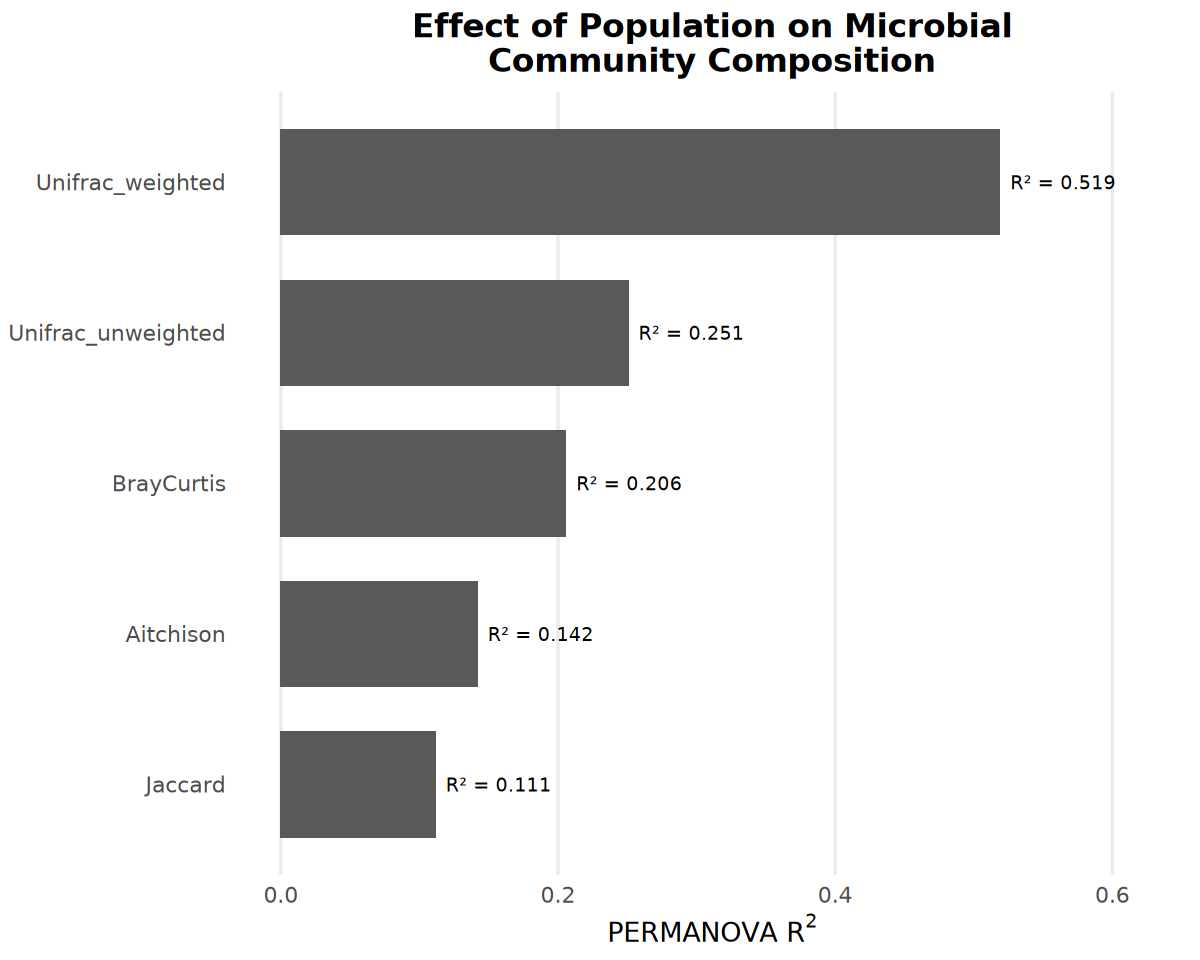

In [335]:
p_permanova <- ggplot(
    permanova_results,
    aes(
        x = reorder(Metric, R2),
        y = R2
    )
) +
    geom_col(
        width = 0.7
    ) +
    geom_text(
        aes(
            label = paste0(
                "R² = ",
                sprintf("%.3f", R2)
            )
        ),
        hjust = -0.1,
        size = 4
    ) +
    coord_flip() +
    labs(
        title = "Effect of Population on Microbial\nCommunity Composition",
        x = NULL,
        y = expression(PERMANOVA~R^2)
    ) +
    theme_minimal(base_size = 16) +
    theme(
        plot.title = element_text(
            face = "bold",
            hjust = 0.5
        ),
        axis.title = element_text(
            face = "bold"
        ),
        panel.grid.major.y = element_blank(),
        panel.grid.minor = element_blank()
    ) +
    expand_limits(
        y = max(permanova_results$R2) * 1.2
    )

p_permanova

In [336]:
# save figure 
# main 
ggsave(
    filename = paste0(FIG_BETA_DIV_DIR, '/', PROJECT_NAME, '.beta_diversity.pop_effect_size.png'),
    plot = p_permanova,
    width = 9,
    height = 9,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_BETA_DIV_DIR, '/', PROJECT_NAME, '.beta_diversity.pop_effect_size.pdf'),
    plot = p_permanova,
    width = 9,
    height = 9,
    units = "in",
    bg = "white"
)


In [320]:
# permanova_results$significance <- cut(
#     permanova_results$p_adj_BH,
#     breaks = c(-Inf, 0.001, 0.01, 0.05, Inf),
#     labels = c("***", "**", "*", "ns")
# )

# geom_text(
#     aes(
#         label = paste0(
#             "R² = ", sprintf("%.3f", R2),
#             "  ", significance
#         )
#     ),
#     hjust = -0.1,
#     size = 4
# )

In [286]:
extract_dispersion_distances <- function(
    stats_list,
    beta_div_metrics,
    metadata,
    group_var = "population_group"
) {

    results <- do.call(
        rbind,
        lapply(beta_div_metrics, function(metric) {

            dispersion <- stats_list[[metric]][["Dispersion"]]

            sample_ids <- names(dispersion$distances)

            data.frame(
                Metric = metric,
                Sample = sample_ids,
                Population = metadata[
                    sample_ids,
                    group_var
                ],
                Distance = as.numeric(
                    dispersion$distances
                ),
                stringsAsFactors = FALSE
            )
        })
    )

    rownames(results) <- NULL

    return(results)
}

In [287]:
dispersion_distances <- extract_dispersion_distances(
    stats_list = stats_list,
    beta_div_metrics = beta_div_metrics,
    metadata = metadata,
    group_var = "population_group"
)

head(dispersion_distances)

,Metric,Sample,Population,Distance
,<chr>,<chr>,<chr>,<dbl>
1,BrayCurtis,10BF,BF,0.4427662
2,BrayCurtis,10EU,EU,0.5701969
3,BrayCurtis,11BF,BF,0.4172150
4,BrayCurtis,11EU,EU,0.5611350
5,BrayCurtis,12BF,BF,0.4465387
6,BrayCurtis,12EU,EU,0.5748181


In [321]:

write_tsv( 
    dispersion_distances,
    file = file.path(SUMMARY_TABLE_DIR, paste0(PROJECT_NAME, ".beta_diversity.Dispersion.Dists.tsv")),
    quote = "needed"
)


In [322]:
permdisp_annot <- permdisp_results %>%
    dplyr::mutate(
        p_label = dplyr::case_when(
            p_adj_BH < 0.001 ~ "***",
            p_adj_BH < 0.01  ~ "**",
            p_adj_BH < 0.05  ~ "*",
            TRUE             ~ "ns"
        )
    ) %>%
    dplyr::left_join(
        dispersion_distances %>%
            dplyr::group_by(Metric) %>%
            dplyr::summarise(
                y.position = max(Distance, na.rm = TRUE) * 1.10,
                .groups = "drop"
            ),
        by = "Metric"
    ) %>%
    dplyr::mutate(
        group1 = "BF",
        group2 = "EU"
    )

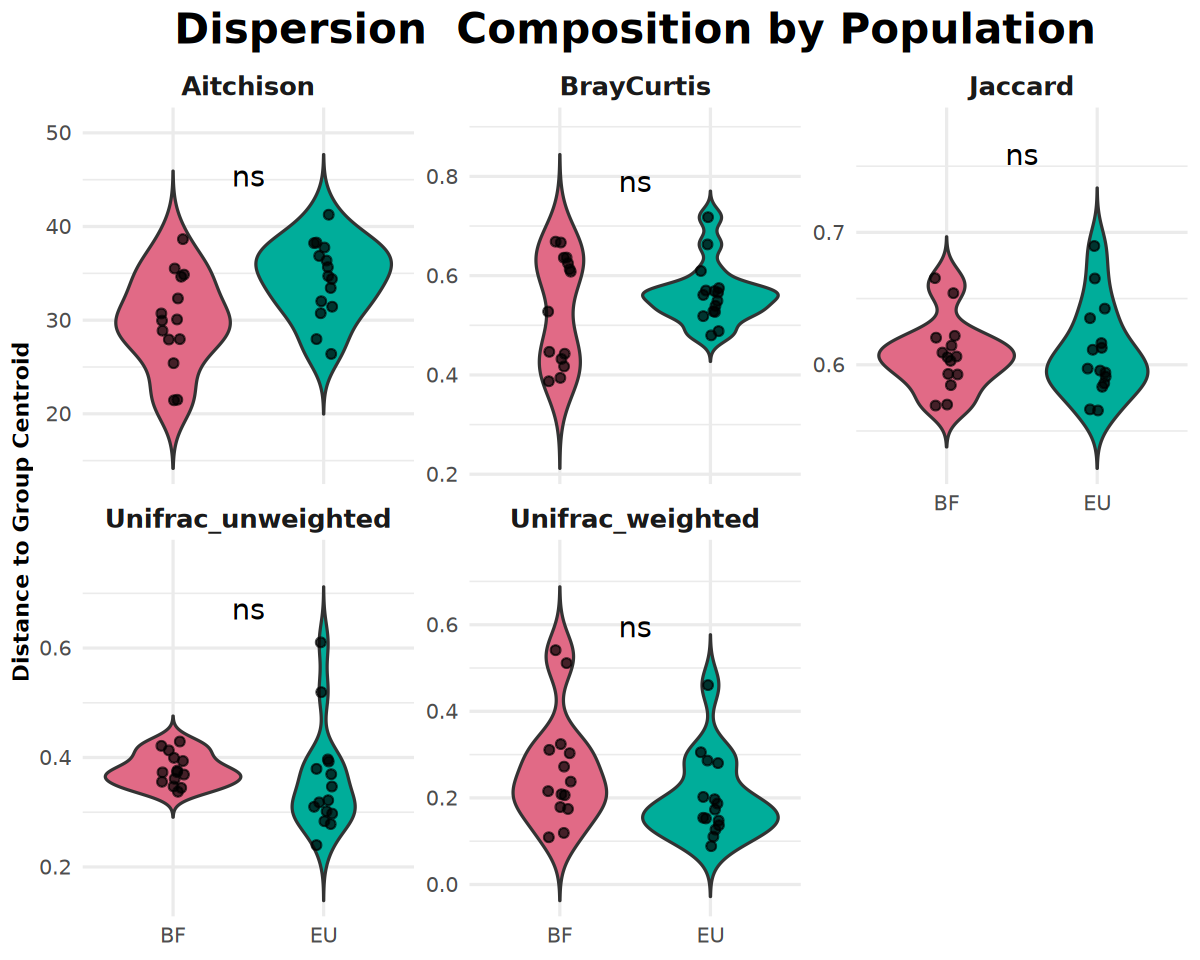

In [339]:
p_dispersion <- ggplot(
    dispersion_distances,
    aes(
        x = Population,
        y = Distance,
        fill = Population
    )
) +
    geom_violin(trim = FALSE) +
    geom_jitter(
        width = 0.08,
        size = 2,
        alpha = 0.7
    ) +
    geom_text(
        data = permdisp_annot,
        aes(
            x = 1.5,
            y = y.position,
            label = p_label
        ),
        inherit.aes = FALSE,
        size = 6
    ) +
    facet_wrap(
        ~ Metric,
        scales = "free_y"
    ) +
    scale_fill_manual(
        values = population_colors
    ) +
    scale_y_continuous(
        expand = expansion(mult = c(0.05, 0.15))
    ) +
    labs(
        title = "Dispersion  Composition by Population",
        x = NULL,
        y = "Distance to Group Centroid"
    ) +
    theme_minimal(base_size = 15) +
    theme(
        legend.position = "none",
        strip.text = element_text(
            size = 15,
            face = "bold"
        ),
          plot.title = element_text(
        size = 25,
        face = "bold",
        hjust = 0.5
    ),
        axis.title = element_text(
        size = 13,
        face = "bold"
    )
    ) 

p_dispersion

In [340]:



# save figure 
# main 
ggsave(
    filename = paste0(FIG_BETA_DIV_DIR, '/', PROJECT_NAME, '.beta_diversity.dispersionComposition.png'),
    plot = p_dispersion,
    width = 18,
    height = 12,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_BETA_DIV_DIR, '/', PROJECT_NAME, '.beta_diversity.dispersionComposition.pdf'),
    plot = p_dispersion,
    width = 18,
    height = 12,
    units = "in",
    bg = "white"
)





write_tsv( 
    permdisp_annot,
    file = file.path(REPORT_TABLE_DIR, paste0(PROJECT_NAME, ".beta_diversity.PermDist_byPop.tsv")),
    quote = "needed"
)




In [329]:
make_beta_stats_table <- function(
    permanova_results,
    permdisp_results
) {

    beta_stats <- permanova_results %>%
        dplyr::select(
            Metric,
            PERMANOVA_R2 = R2,
            PERMANOVA_F = F,
            PERMANOVA_p = p_value,
            PERMANOVA_p_adj_BH = p_adj_BH
        ) %>%
        dplyr::left_join(
            permdisp_results %>%
                dplyr::select(
                    Metric,
                    PERMDISP_F = F,
                    PERMDISP_p = p_value,
                    PERMDISP_p_adj_BH = p_adj_BH
                ),
            by = "Metric"
        ) %>%
        dplyr::mutate(
            Metric = dplyr::recode(
                Metric,
                "BrayCurtis" = "Bray–Curtis",
                "Jaccard" = "Jaccard",
                "Aitchison" = "Aitchison",
                "Unifrac_weighted" = "Weighted UniFrac",
                "Unifrac_unweighted" = "Unweighted UniFrac"
            ),
            dplyr::across(
                c(PERMANOVA_R2, PERMANOVA_F, PERMDISP_F),
                ~ round(.x, 3)
            )
        )

    return(beta_stats)
}

In [330]:
beta_stats_table <- make_beta_stats_table(
    permanova_results = permanova_results,
    permdisp_results = permdisp_results
)

beta_stats_table

Metric,PERMANOVA_R2,PERMANOVA_F,PERMANOVA_p,PERMANOVA_p_adj_BH,PERMDISP_F,PERMDISP_p,PERMDISP_p_adj_BH
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Bray–Curtis,0.206,6.990,1e-04,1e-04,0.738,0.3912,0.590375
Jaccard,0.111,3.382,1e-04,1e-04,0.038,0.8535,0.853500
Aitchison,0.142,4.461,1e-04,1e-04,6.621,0.0154,0.077000
Weighted UniFrac,0.519,29.102,1e-04,1e-04,2.357,0.1420,0.355000
Unweighted UniFrac,0.251,9.024,1e-04,1e-04,0.571,0.4723,0.590375


In [331]:


write_tsv( 
    beta_stats_table,
    file = file.path(REPORT_TABLE_DIR, paste0(PROJECT_NAME, ".beta_diversity.CombinedStatistics_PERM.tsv")),
    quote = "needed"
)
